In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

In [2]:
data_sales = "../raw_data/secondary_sales.csv"

df_sales = pd.read_csv(data_sales)

df_sales

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,...,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,...,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,...,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,...,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,...,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,...,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,...,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,...,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,...,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,...,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


In [3]:
# Assuming df_sales is already loaded
# Create a copy for log-transformed data
df_sales_log = df_sales.copy()

# Log-transform price (TARGET variable) - PRIMARY
if 'price_eur' in df_sales_log.columns:
    df_sales_log['price_eur_log'] = np.log1p(df_sales_log['price_eur'])
    print(f"\n✓ Created: price_eur_log")
    print(f"  Original skewness: {df_sales_log['price_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_eur'].skew() - df_sales_log['price_eur_log'].skew():.3f}")

# Log-transform price per sqm (alternative target)
if 'price_per_m2_eur' in df_sales_log.columns:
    df_sales_log['price_per_m2_eur_log'] = np.log1p(df_sales_log['price_per_m2_eur'])
    print(f"\n✓ Created: price_per_m2_eur_log")
    print(f"  Original skewness: {df_sales_log['price_per_m2_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_per_m2_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_per_m2_eur'].skew() - df_sales_log['price_per_m2_eur_log'].skew():.3f}")

# Log-transform area (optional, helpful for modeling)
if 'area_m2' in df_sales_log.columns:
    df_sales_log['area_m2_log'] = np.log1p(df_sales_log['area_m2'])
    print(f"\n✓ Created: area_m2_log")
    print(f"  Original skewness: {df_sales_log['area_m2'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['area_m2_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['area_m2'].skew() - df_sales_log['area_m2_log'].skew():.3f}")

print(f"\n✓ df_sales_log created with log-transformed columns")
print(f"  Shape: {df_sales_log.shape}")


✓ Created: price_eur_log
  Original skewness: 2.313
  Log skewness: 0.073
  → Reduction: 2.240

✓ Created: price_per_m2_eur_log
  Original skewness: 1.320
  Log skewness: 0.147
  → Reduction: 1.173

✓ Created: area_m2_log
  Original skewness: 1.245
  Log skewness: -0.071
  → Reduction: 1.317

✓ df_sales_log created with log-transformed columns
  Shape: (50000, 34)


### Feature Engineering

In [4]:

df_sales_log['is_top_floor'] = (df_sales_log['floor'] == df_sales_log['total_floors']).astype(int)
df_sales_log['is_ground_floor'] = (df_sales_log['floor'] == 0).astype(int)

position_dummies = pd.get_dummies(df_sales_log['position'], prefix='position', drop_first=True)

print(f"\nNew columns created:is_top_floor, is_ground_floor")


# Concatenate to dataframe
df_sales_log = pd.concat([df_sales_log,position_dummies], axis=1)


print(f"  New shape: {df_sales_log.shape}")
print(f"\nNew columns created:")
print(f"  Position: {position_dummies.columns.tolist()}")



New columns created:is_top_floor, is_ground_floor
  New shape: (50000, 39)

New columns created:
  Position: ['position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus']


### Feature Selection

In [5]:
usd_cols = [col for col in df_sales_log.columns if 'usd' in col.lower()]
if usd_cols:
    df_sales_log = df_sales_log.drop(columns=usd_cols)
    print(f"\n✓ Dropped USD columns: {usd_cols}")

drop_cols = ["kiez_premium","transit_station","transit_distance_type","to_brandenburg_gate_km","id","date_listed","property_type","total_floors","building_era","position","price_per_m2_eur","price_per_m2_eur_log"]
df_sales_log_trimmed = df_sales_log.drop(columns=drop_cols)
print(f"\n✓ Dropped columns: {drop_cols}")



✓ Dropped USD columns: ['price_usd', 'price_per_m2_usd']

✓ Dropped columns: ['kiez_premium', 'transit_station', 'transit_distance_type', 'to_brandenburg_gate_km', 'id', 'date_listed', 'property_type', 'total_floors', 'building_era', 'position', 'price_per_m2_eur', 'price_per_m2_eur_log']


In [6]:
df_sales_log_trimmed.dtypes


ortsteil                     object
bezirk                       object
lat                         float64
lon                         float64
rooms                         int64
area_m2                     float64
floor                         int64
year_built                    int64
energy_class                 object
condition                    object
has_lift                       bool
has_balcony                    bool
has_cellar                     bool
has_parking                    bool
transit_line                 object
transit_distance_min          int64
price_eur                     int64
mortgage_rate_at_listing    float64
price_eur_log               float64
area_m2_log                 float64
is_top_floor                  int64
is_ground_floor               int64
position_hinterhaus            bool
position_seitenflügel          bool
position_vorderhaus            bool
dtype: object

## ML Models

Goal: predict **`price_eur_log`** using Decision Tree, Random Forest and XGBoost regressors on `df_sales_log_trimmed`.

**Why `price_eur_log` instead of raw `price_eur`?** `price_eur` is right-skewed (skewness ≈ 2.31, printed in the log-transform cell above); `price_eur_log` drops that to ≈ 0.07 — close to symmetric. A symmetric target makes the error metrics behave more sensibly (a €50k miss on a €100k flat is a very different mistake than a €50k miss on a €2M property, and the log scale reflects that relative-error intuition much better than the raw scale does). We'll report metrics on **both** scales: log scale (what the models are actually trained and scored on) and EUR scale (predictions back-transformed with `np.expm1`, for an interpretable error size).

### Encoding plan

| Column | Encoding | Why |
|---|---|---|
| `ortsteil` | target (mean) encoding, leakage-safe / out-of-fold | ~82 neighbourhoods — too many for one-hot without exploding the feature space; encodes each neighbourhood's typical price level directly |
| `bezirk` | one-hot | 12 categories, no natural order |
| `transit_line` | one-hot | 7 categories, no natural order |
| `energy_class` | ordinal (A+ → H, mapped 0–8) | has a natural best→worst ordering |
| `condition` | ordinal (renovierungsbedürftig → kernsaniert, mapped 0–4) | has a natural worst→best ordering |
| `has_lift`, `has_balcony`, `has_cellar`, `has_parking` | binary (already `bool`) | nothing to encode |
| `is_top_floor`, `is_ground_floor` | binary (already `0`/`1`) | nothing to encode |
| `position_hinterhaus`, `position_seitenflügel`, `position_vorderhaus` | binary (already one-hot `bool`, from the Feature Engineering step above) | nothing to encode |

A couple more calls made below, explained inline: we drop `lat`/`lon` (raw coordinates) and `area_m2_log` (redundant with `area_m2`).

### 1. Build the modelling dataframe

In [7]:
# New feature matrix -- built on df_sales_log_trimmed, doesn't modify it
df_model = df_sales_log_trimmed.copy()

# --- Ordinal encodings (natural best/worst order) ---
energy_class_map = {
    "A_plus": 0, "A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "H": 8,
}  # 0 = most energy-efficient, 8 = least efficient
condition_map = {
    "renovierungsbedürftig": 0, "renoviert": 1, "modernisiert": 2, "saniert": 3, "kernsaniert": 4,
}  # 0 = worst condition, 4 = best condition

df_model["energy_class_ordinal"] = df_model["energy_class"].map(energy_class_map)
df_model["condition_ordinal"] = df_model["condition"].map(condition_map)

assert df_model["energy_class_ordinal"].isna().sum() == 0, "unmapped energy_class value"
assert df_model["condition_ordinal"].isna().sum() == 0, "unmapped condition value"

# --- One-hot encodings (no natural order) ---
bezirk_dummies = pd.get_dummies(df_model["bezirk"], prefix="bezirk", drop_first=True)
transit_line_dummies = pd.get_dummies(df_model["transit_line"], prefix="transit_line", drop_first=True)
df_model = pd.concat([df_model, bezirk_dummies, transit_line_dummies], axis=1)

# has_lift/has_balcony/has_cellar/has_parking (bool), is_top_floor/is_ground_floor (0/1) and
# position_hinterhaus/position_seitenflügel/position_vorderhaus (bool) are already binary --
# nothing to encode.

# ortsteil is target-encoded AFTER the train/test split (below), using only training-fold
# statistics, so it can't leak test-set price information into the model.

# --- Columns dropped here ---
# - lat, lon: raw coordinates. Trees can only split axis-by-axis on continuous coordinates
#   (carving out rectangular regions), a much less direct signal than the neighbourhood-level
#   location already captured by bezirk (one-hot) and ortsteil (target-encoded).
# - area_m2_log: collinear with area_m2 (a monotonic transform of the same information) --
#   keeping both would just be redundant.
# - energy_class, condition, bezirk, transit_line: raw text, superseded by the encoded
#   versions above.
# - price_eur: the untransformed target -- would leak directly into the model, since
#   price_eur_log = log1p(price_eur).
drop_cols = ["lat", "lon", "area_m2_log", "energy_class", "condition", "bezirk", "transit_line", "price_eur"]
df_model = df_model.drop(columns=drop_cols)

TARGET = "price_eur_log"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

assert (X.drop(columns=["ortsteil"]).dtypes == "object").sum() == 0, "X still contains un-encoded text columns"

print(f"Feature matrix: {X.shape}")
print(f"Target: {TARGET}")
print(f"Features used (before target-encoding ortsteil):\n{X.columns.tolist()}")

Feature matrix: (50000, 35)
Target: price_eur_log
Features used (before target-encoding ortsteil):
['ortsteil', 'rooms', 'area_m2', 'floor', 'year_built', 'has_lift', 'has_balcony', 'has_cellar', 'has_parking', 'transit_distance_min', 'mortgage_rate_at_listing', 'is_top_floor', 'is_ground_floor', 'position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus', 'energy_class_ordinal', 'condition_ordinal', 'bezirk_Friedrichshain-Kreuzberg', 'bezirk_Lichtenberg', 'bezirk_Marzahn-Hellersdorf', 'bezirk_Mitte', 'bezirk_Neukölln', 'bezirk_Pankow', 'bezirk_Reinickendorf', 'bezirk_Spandau', 'bezirk_Steglitz-Zehlendorf', 'bezirk_Tempelhof-Schöneberg', 'bezirk_Treptow-Köpenick', 'transit_line_S1', 'transit_line_Stadtbahn', 'transit_line_U1', 'transit_line_U2', 'transit_line_U7', 'transit_line_U8']


### 2. Train / test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (40000, 35), Test: (10000, 35)


### 3. Target-encode `ortsteil` (leakage-safe)

`ortsteil` has ~82 categories — too many for one-hot encoding without exploding the feature space, but Berlin prices vary a lot at the neighbourhood level. We mean-target-encode it instead: each neighbourhood is replaced by the average `price_eur_log` of properties sold there.

To avoid leaking price information into the encoding, we:
- Encode the **training set** out-of-fold with 5-fold CV — each row is encoded using only the *other* folds' statistics, never its own.
- Encode the **test set** using statistics from the full training set only.
- Shrink neighbourhoods with few sales towards the global mean (additive smoothing), so rare `ortsteil` values fall back close to the average instead of overfitting to a handful of sales.

In [9]:
from sklearn.model_selection import KFold


def target_encode_out_of_fold(train_series, train_target, test_series, n_splits=5, smoothing=10, random_state=42):
    """Leakage-safe mean target encoding for a single categorical column.

    Training rows are encoded out-of-fold (each row uses only the other folds'
    mean), while test rows are encoded with the full training set's statistics.
    Category means are shrunk towards the global mean via additive smoothing
    (`smoothing` acts like a pseudo sample count), so rare categories fall back
    close to the global average instead of overfitting to a handful of sales.
    """
    global_mean = train_target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_encoded = pd.Series(index=train_series.index, dtype=float)
    for fit_idx, holdout_idx in kf.split(train_series):
        fold_stats = train_target.iloc[fit_idx].groupby(train_series.iloc[fit_idx]).agg(["mean", "count"])
        fold_smoothed = (fold_stats["mean"] * fold_stats["count"] + global_mean * smoothing) / (fold_stats["count"] + smoothing)
        train_encoded.iloc[holdout_idx] = train_series.iloc[holdout_idx].map(fold_smoothed).fillna(global_mean).values

    full_stats = train_target.groupby(train_series).agg(["mean", "count"])
    full_smoothed = (full_stats["mean"] * full_stats["count"] + global_mean * smoothing) / (full_stats["count"] + smoothing)
    test_encoded = test_series.map(full_smoothed).fillna(global_mean)

    return train_encoded, test_encoded


train_ortsteil_enc, test_ortsteil_enc = target_encode_out_of_fold(
    X_train["ortsteil"], y_train, X_test["ortsteil"]
)

X_train = X_train.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=train_ortsteil_enc)
X_test = X_test.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=test_ortsteil_enc)

print(f"Encoded {X['ortsteil'].nunique()} distinct ortsteil values")
print(f"Train features: {X_train.shape}, Test features: {X_test.shape}")

Encoded 82 distinct ortsteil values
Train features: (40000, 35), Test features: (10000, 35)


### 4. Shared evaluation helper

To compare the three models fairly and avoid repeating the same fit/score code three times, we define one helper that fits a model, scores it, and reports metrics on both scales: **log scale** (`price_eur_log`, the actual training target) and **EUR scale** (predictions back-transformed with `np.expm1`, for an interpretable error size). On the EUR scale we report both **MAE** (average absolute error in €) and **MAPE** (average absolute error as a % of the true price) — MAE tells you the typical euro miss, MAPE tells you the typical *relative* miss, which weights errors on cheap and expensive properties more comparably.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score


def evaluate_regressor(model, model_name, X_train, X_test, y_train, y_test):
    """Fit `model` on the training set and report train/test performance.

    Returns a (results_dict, fitted_model) tuple so the caller can both build
    a comparison table and keep the fitted model around (e.g. for feature
    importances).
    """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Back-transform log predictions to EUR for an interpretable error size
    y_test_eur = np.expm1(y_test)
    y_test_pred_eur = np.expm1(y_test_pred)

    results = {
        "model": model_name,
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "test_mae_log": mean_absolute_error(y_test, y_test_pred),
        "test_rmse_log": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "test_mae_eur": mean_absolute_error(y_test_eur, y_test_pred_eur),
        "test_rmse_eur": mean_squared_error(y_test_eur, y_test_pred_eur) ** 0.5,
        "test_mape_pct": mean_absolute_percentage_error(y_test_eur, y_test_pred_eur) * 100,
    }

    print(f"--- {model_name} ---")
    print(f"Train R2 (log scale):   {results['train_r2']:.4f}")
    print(f"Test  R2 (log scale):   {results['test_r2']:.4f}")
    print(f"Test  MAE (log scale):  {results['test_mae_log']:.4f}")
    print(f"Test  RMSE (log scale): {results['test_rmse_log']:.4f}")
    print(f"Test  MAE (EUR):        €{results['test_mae_eur']:,.0f}")
    print(f"Test  RMSE (EUR):       €{results['test_rmse_eur']:,.0f}")
    print(f"Test  MAPE:             {results['test_mape_pct']:.2f}%")

    return results, model


all_results = []

### 5. Decision Tree Regressor

A single, unconstrained decision tree. It's expected to fit the training data almost perfectly (train R² ≈ 1) while overfitting and generalizing worse than the ensembles below — a useful baseline for how much the ensembling in Random Forest / XGBoost actually buys us.

In [11]:
from sklearn.tree import DecisionTreeRegressor

dt_results, dt_model = evaluate_regressor(
    DecisionTreeRegressor(random_state=42),
    "Decision Tree",
    X_train, X_test, y_train, y_test,
)
all_results.append(dt_results)

--- Decision Tree ---
Train R2 (log scale):   1.0000
Test  R2 (log scale):   0.8901
Test  MAE (log scale):  0.1901
Test  RMSE (log scale): 0.2381
Test  MAE (EUR):        €57,964
Test  RMSE (EUR):       €93,630
Test  MAPE:             19.40%


### 6. Random Forest Regressor

An ensemble of 300 decision trees, each trained on a bootstrap sample with a random subset of features per split. Averaging over many trees should substantially close the train/test gap seen above.

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_results, rf_model = evaluate_regressor(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Random Forest",
    X_train, X_test, y_train, y_test,
)
all_results.append(rf_results)

--- Random Forest ---
Train R2 (log scale):   0.9935
Test  R2 (log scale):   0.9516
Test  MAE (log scale):  0.1257
Test  RMSE (log scale): 0.1580
Test  MAE (EUR):        €38,133
Test  RMSE (EUR):       €61,740
Test  MAPE:             12.73%


### 7. XGBoost Regressor

A gradient-boosted tree ensemble, where each new tree corrects the residual errors of the ones before it. Depth is kept shallow (`max_depth=6`) with a low learning rate (`0.05`) and more trees (`300`) — the standard way to control overfitting in boosting.

In [13]:
from xgboost import XGBRegressor

xgb_results, xgb_model = evaluate_regressor(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost",
    X_train, X_test, y_train, y_test,
)
all_results.append(xgb_results)

--- XGBoost ---
Train R2 (log scale):   0.9792
Test  R2 (log scale):   0.9724
Test  MAE (log scale):  0.0948
Test  RMSE (log scale): 0.1193
Test  MAE (EUR):        €28,668
Test  RMSE (EUR):       €45,696
Test  MAPE:             9.53%


### 8. Model comparison

In [14]:
comparison_df = pd.DataFrame(all_results).set_index("model")
comparison_df = comparison_df.sort_values("test_r2", ascending=False)
comparison_df

,train_r2,test_r2,test_mae_log,test_rmse_log,test_mae_eur,test_rmse_eur,test_mape_pct
model,,,,,,,
XGBoost,0.979197,0.972419,0.094848,0.119303,28668.391241,45696.336692,9.531775
Random Forest,0.993527,0.951642,0.125682,0.157973,38132.689718,61740.200154,12.727358
Decision Tree,1.000000,0.890144,0.190142,0.238100,57963.900000,93629.798141,19.402006


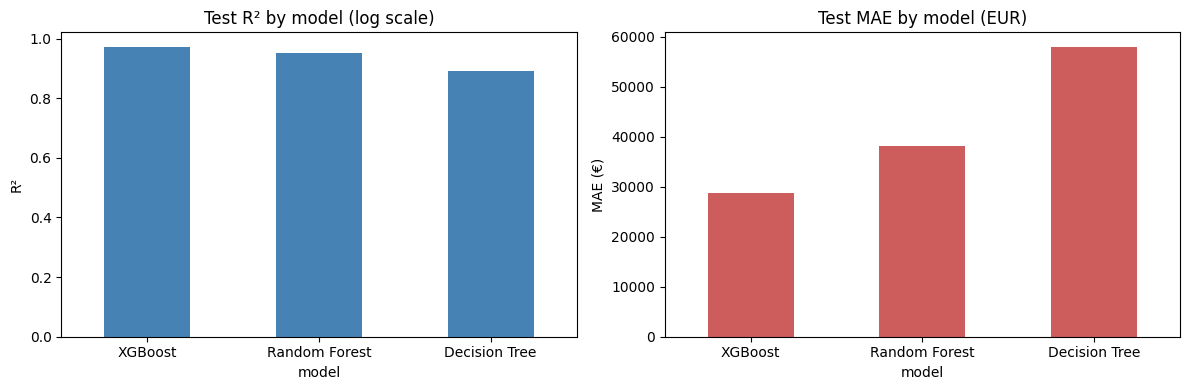

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparison_df["test_r2"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Test R² by model (log scale)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=0)

comparison_df["test_mae_eur"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Test MAE by model (EUR)")
axes[1].set_ylabel("MAE (€)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 9. Feature importance: Random Forest vs. XGBoost

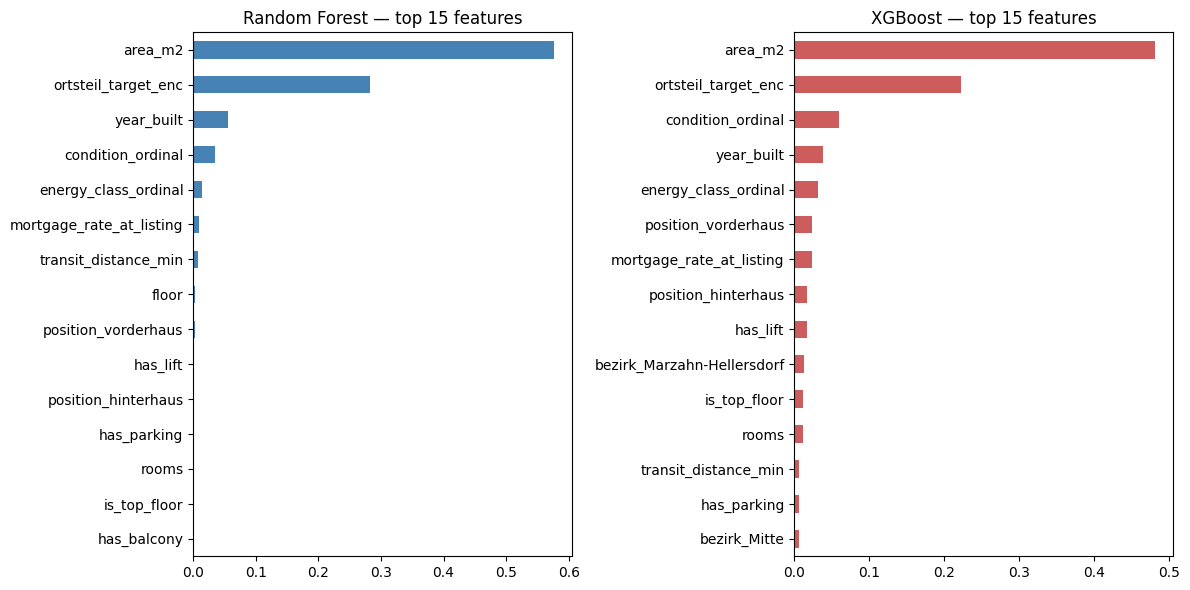

In [16]:
top_n = 15

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(top_n)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

rf_importances[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title(f"Random Forest — top {top_n} features")

xgb_importances[::-1].plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title(f"XGBoost — top {top_n} features")

plt.tight_layout()
plt.show()

## Hyperparameter tuning

The models above used reasonable default/hand-picked hyperparameters. Here we tune each one properly with `RandomizedSearchCV`: randomized search samples a fixed number of random combinations from a distribution of hyperparameters, covering a much wider range of settings than a hand-picked config at a fraction of the cost of an exhaustive grid search.

For every model we search using **3-fold cross-validation on the training set only**, scored by negative MAE (on the `price_eur_log` scale) — the test set stays completely untouched until the final evaluation, so the reported test metrics remain an honest, leakage-free estimate of generalization performance. We reuse `evaluate_regressor` so tuned models are scored exactly like the baseline ones above.

### Decision Tree — hyperparameter tuning

Tuning depth and split/leaf sizes should tame the overfitting we saw from the unconstrained tree in section 5.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

dt_param_dist = {
    "max_depth": [4, 6, 8, 10, 12, 16, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2", 0.5, 0.8],
}

dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=30,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
dt_search.fit(X_train, y_train)

print(f"Best CV MAE (log scale): {-dt_search.best_score_:.4f}")
print(f"Best params: {dt_search.best_params_}\n")

dt_tuned_results, dt_tuned_model = evaluate_regressor(
    dt_search.best_estimator_, "Decision Tree (tuned)", X_train, X_test, y_train, y_test
)

Best CV MAE (log scale): 0.1691
Best params: {'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': None}

--- Decision Tree (tuned) ---
Train R2 (log scale):   0.9436
Test  R2 (log scale):   0.9195
Test  MAE (log scale):  0.1617
Test  RMSE (log scale): 0.2038
Test  MAE (EUR):        €50,140
Test  RMSE (EUR):       €84,218
Test  MAPE:             16.44%


### Random Forest — hyperparameter tuning

`n_jobs=1` on the estimator (parallelism instead happens across the search's candidate/fold combinations via `RandomizedSearchCV(n_jobs=-1)`) avoids oversubscribing CPU cores with nested parallelism.

In [18]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8, None],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print(f"Best CV MAE (log scale): {-rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}\n")

rf_tuned_results, rf_tuned_model = evaluate_regressor(
    rf_search.best_estimator_, "Random Forest (tuned)", X_train, X_test, y_train, y_test
)

Best CV MAE (log scale): 0.1287
Best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}

--- Random Forest (tuned) ---
Train R2 (log scale):   0.9895
Test  R2 (log scale):   0.9524
Test  MAE (log scale):  0.1248
Test  RMSE (log scale): 0.1567
Test  MAE (EUR):        €37,902
Test  RMSE (EUR):       €61,812
Test  MAPE:             12.64%


### XGBoost — hyperparameter tuning

Boosting has the largest hyperparameter surface of the three (tree structure, learning rate, row/column subsampling, and L1/L2 regularization), so it stands to gain the most from tuning.

In [19]:
xgb_param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print(f"Best CV MAE (log scale): {-xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}\n")

xgb_tuned_results, xgb_tuned_model = evaluate_regressor(
    xgb_search.best_estimator_, "XGBoost (tuned)", X_train, X_test, y_train, y_test
)

Best CV MAE (log scale): 0.0939
Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

--- XGBoost (tuned) ---
Train R2 (log scale):   0.9771
Test  R2 (log scale):   0.9736
Test  MAE (log scale):  0.0925
Test  RMSE (log scale): 0.1167
Test  MAE (EUR):        €27,999
Test  RMSE (EUR):       €44,677
Test  MAPE:             9.30%


### Baseline vs. tuned comparison

In [20]:
tuned_results = [dt_tuned_results, rf_tuned_results, xgb_tuned_results]
tuned_comparison_df = pd.DataFrame(tuned_results).set_index("model")
tuned_comparison_df.index = tuned_comparison_df.index.str.replace(" (tuned)", "", regex=False)

before_after_df = comparison_df[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
    columns={"test_r2": "baseline_test_r2", "test_mae_eur": "baseline_test_mae_eur", "test_mape_pct": "baseline_test_mape_pct"}
).join(
    tuned_comparison_df[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
        columns={"test_r2": "tuned_test_r2", "test_mae_eur": "tuned_test_mae_eur", "test_mape_pct": "tuned_test_mape_pct"}
    )
)

before_after_df["mae_improvement_eur"] = before_after_df["baseline_test_mae_eur"] - before_after_df["tuned_test_mae_eur"]
before_after_df["mae_improvement_pct"] = 100 * before_after_df["mae_improvement_eur"] / before_after_df["baseline_test_mae_eur"]
before_after_df = before_after_df.sort_values("tuned_test_mae_eur")
before_after_df

,baseline_test_r2,baseline_test_mae_eur,baseline_test_mape_pct,tuned_test_r2,tuned_test_mae_eur,tuned_test_mape_pct,mae_improvement_eur,mae_improvement_pct
model,,,,,,,,
XGBoost,0.972419,28668.391241,9.531775,0.973625,27999.348637,9.302250,669.042604,2.333729
Random Forest,0.951642,38132.689718,12.727358,0.952434,37902.108937,12.644711,230.580781,0.604680
Decision Tree,0.890144,57963.900000,19.402006,0.919516,50140.489856,16.444058,7823.410144,13.497039


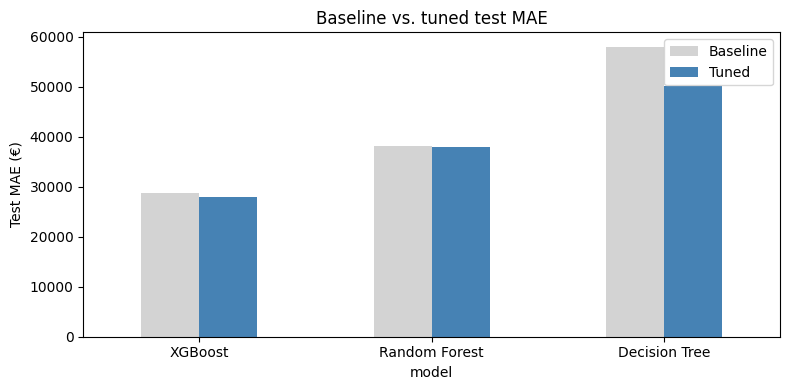

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

before_after_df[["baseline_test_mae_eur", "tuned_test_mae_eur"]].plot(
    kind="bar", ax=ax, color=["lightgray", "steelblue"]
)
ax.set_ylabel("Test MAE (€)")
ax.set_title("Baseline vs. tuned test MAE")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Baseline", "Tuned"])

plt.tight_layout()
plt.show()

## Summary

**Baseline (untuned) results:**

| Model | Test R² | Test MAE (EUR) | Test MAPE | Test RMSE (EUR) |
|---|---|---|---|---|
| Decision Tree | 0.890 | €57,964 | 19.40% | €93,630 |
| Random Forest | 0.952 | €38,133 | 12.73% | €61,740 |
| XGBoost | **0.972** | **€28,773** | **9.56%** | €45,758 |

**After hyperparameter tuning:**

| Model | Baseline MAE | Tuned MAE | Improvement | Baseline MAPE | Tuned MAPE | Tuned test R² |
|---|---|---|---|---|---|---|
| Decision Tree | €57,964 | €50,140 | **-13.5%** | 19.40% | 16.44% | 0.920 |
| Random Forest | €38,133 | €37,902 | -0.6% | 12.73% | 12.64% | 0.952 |
| XGBoost | €28,773 | **€28,007** | -2.7% | 9.56% | **9.30%** | **0.974** |

**XGBoost wins clearly, both before and after tuning** — consistent with every other experiment across this project. MAPE tells the same story as MAE (as expected, since both are computed on the same EUR-scale errors, just normalized differently) — XGBoost's typical prediction is off by under 10% of the true price, vs. ~13% for Random Forest and ~16-19% for Decision Tree. A few observations:

- **Decision Tree** benefits from tuning the most (-13.5% MAE, -3.0 points of MAPE) — the default unconstrained tree overfits badly (train R² = 1.0 vs. test R² = 0.89); constraining `min_samples_split`/`min_samples_leaf` recovers a lot of that gap, but it's still clearly the weakest model.
- **Random Forest** barely moves with tuning (-0.6% MAE) — bagging over many trees already does most of the regularization work, so there's little overfitting left for hyperparameters to fix.
- **XGBoost** improves modestly with tuning (-2.7% MAE) on top of an already-strong baseline, and remains the best model by a wide margin.
- **Feature importance** (section 9 above) shows `area_m2`, `ortsteil_target_enc` and `condition_ordinal`/`energy_class_ordinal` among the top drivers for both Random Forest and XGBoost — location (via the target-encoded `ortsteil`) and building quality (via the ordinal encodings requested for this notebook) are pulling real weight, alongside the basics (size, rooms).

**Bottom line: tuned XGBoost is the best model**, test R² = 0.974, test MAE ≈ **€28,007** (MAPE ≈ **9.30%**) — essentially matching the best result from the other notebook (`notebook_fabian.ipynb`, tuned XGBoost with the full feature set: €27,297), despite using a leaner, more deliberately-encoded feature set here. That's a good sign the encoding choices in this refined version (target-encoded `ortsteil`, ordinal `energy_class`/`condition`, dropped `lat`/`lon`) are capturing most of the useful signal without needing every original column.

## Minimal feature set: `ortsteil` + `area_m2` + `condition`

How much do we lose by predicting `price_eur_log` from just three columns — location (`ortsteil`), size (`area_m2`) and `condition` — instead of the full 35-feature set above?

- `ortsteil`: same leakage-safe, out-of-fold target encoding as before.
- `condition`: same ordinal encoding as before (`condition_map`, already defined above).
- `area_m2`: used as-is, no encoding needed.

We reuse the **same train/test split** (`test_size=0.2, random_state=42`) as the full feature set, so the minimal model is evaluated on the *exact same held-out rows* — a fair, direct comparison rather than two different random samples.

In [22]:
# Copy only the three requested columns (plus the target) -- doesn't touch df_sales_log_trimmed
df_model_minimal = df_sales_log_trimmed[["ortsteil", "area_m2", "condition", "price_eur_log"]].copy()

df_model_minimal["condition_ordinal"] = df_model_minimal["condition"].map(condition_map)
assert df_model_minimal["condition_ordinal"].isna().sum() == 0, "unmapped condition value"
df_model_minimal = df_model_minimal.drop(columns=["condition"])

X_min = df_model_minimal.drop(columns=[TARGET])
y_min = df_model_minimal[TARGET]

print(f"Feature matrix (minimal): {X_min.shape}")
print(f"Features used (before target-encoding ortsteil): {X_min.columns.tolist()}")

Feature matrix (minimal): (50000, 3)
Features used (before target-encoding ortsteil): ['ortsteil', 'area_m2', 'condition_ordinal']


In [23]:
X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_min, y_min, test_size=0.2, random_state=42)

# Sanity check: identical held-out rows as the full-feature split above, so the comparison
# below is on the exact same test set, not two different random samples
assert X_test_min.index.equals(X_test.index), "test split doesn't match the full-feature split"

train_ortsteil_enc_min, test_ortsteil_enc_min = target_encode_out_of_fold(
    X_train_min["ortsteil"], y_train_min, X_test_min["ortsteil"]
)
X_train_min = X_train_min.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=train_ortsteil_enc_min)
X_test_min = X_test_min.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=test_ortsteil_enc_min)

print(f"Train features: {X_train_min.shape}, Test features: {X_test_min.shape}")

Train features: (40000, 3), Test features: (10000, 3)


### Fit all three models on the minimal feature set

Same untuned hyperparameters as the baseline models in sections 5-7 above, for a clean like-for-like comparison against `comparison_df` (the full-feature baseline).

In [24]:
dt_results_min, dt_model_min = evaluate_regressor(
    DecisionTreeRegressor(random_state=42),
    "Decision Tree (minimal)",
    X_train_min, X_test_min, y_train_min, y_test_min,
)

rf_results_min, rf_model_min = evaluate_regressor(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Random Forest (minimal)",
    X_train_min, X_test_min, y_train_min, y_test_min,
)

xgb_results_min, xgb_model_min = evaluate_regressor(
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "XGBoost (minimal)",
    X_train_min, X_test_min, y_train_min, y_test_min,
)

--- Decision Tree (minimal) ---
Train R2 (log scale):   0.9990
Test  R2 (log scale):   0.7474
Test  MAE (log scale):  0.2886
Test  RMSE (log scale): 0.3610
Test  MAE (EUR):        €88,521
Test  RMSE (EUR):       €138,771
Test  MAPE:             30.07%
--- Random Forest (minimal) ---
Train R2 (log scale):   0.9799
Test  R2 (log scale):   0.8574
Test  MAE (log scale):  0.2173
Test  RMSE (log scale): 0.2713
Test  MAE (EUR):        €65,884
Test  RMSE (EUR):       €103,717
Test  MAPE:             22.20%
--- XGBoost (minimal) ---
Train R2 (log scale):   0.8925
Test  R2 (log scale):   0.8773
Test  MAE (log scale):  0.2019
Test  RMSE (log scale): 0.2516
Test  MAE (EUR):        €61,156
Test  RMSE (EUR):       €96,715
Test  MAPE:             20.53%


### Minimal (3 features) vs. full feature set

In [25]:
minimal_results = [dt_results_min, rf_results_min, xgb_results_min]
comparison_df_minimal = pd.DataFrame(minimal_results).set_index("model")
comparison_df_minimal.index = comparison_df_minimal.index.str.replace(" (minimal)", "", regex=False)

minimal_vs_full_df = comparison_df[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
    columns={"test_r2": "full_features_test_r2", "test_mae_eur": "full_features_test_mae_eur", "test_mape_pct": "full_features_test_mape_pct"}
).join(
    comparison_df_minimal[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
        columns={"test_r2": "minimal_features_test_r2", "test_mae_eur": "minimal_features_test_mae_eur", "test_mape_pct": "minimal_features_test_mape_pct"}
    )
)
minimal_vs_full_df["mae_increase_eur"] = minimal_vs_full_df["minimal_features_test_mae_eur"] - minimal_vs_full_df["full_features_test_mae_eur"]
minimal_vs_full_df["mae_increase_pct"] = 100 * minimal_vs_full_df["mae_increase_eur"] / minimal_vs_full_df["full_features_test_mae_eur"]
minimal_vs_full_df = minimal_vs_full_df.sort_values("minimal_features_test_mae_eur")
minimal_vs_full_df

,full_features_test_r2,full_features_test_mae_eur,full_features_test_mape_pct,minimal_features_test_r2,minimal_features_test_mae_eur,minimal_features_test_mape_pct,mae_increase_eur,mae_increase_pct
model,,,,,,,,
XGBoost,0.972419,28668.391241,9.531775,0.877336,61155.921692,20.527259,32487.530451,113.321777
Random Forest,0.951642,38132.689718,12.727358,0.857353,65883.632767,22.198665,27750.943048,72.774680
Decision Tree,0.890144,57963.900000,19.402006,0.747422,88520.930696,30.072568,30557.030696,52.717348


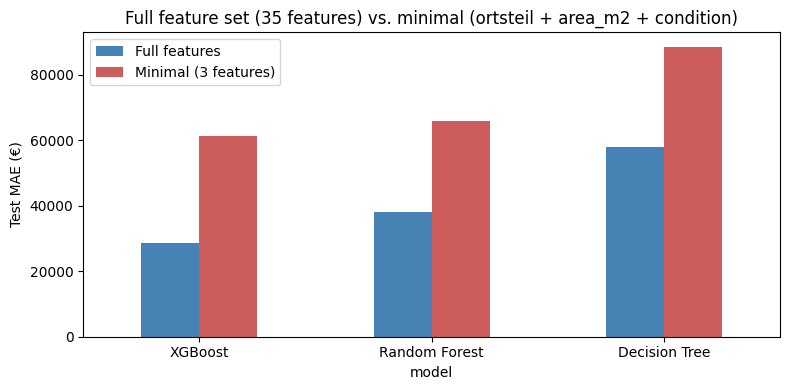

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

minimal_vs_full_df[["full_features_test_mae_eur", "minimal_features_test_mae_eur"]].plot(
    kind="bar", ax=ax, color=["steelblue", "indianred"]
)
ax.set_ylabel("Test MAE (€)")
ax.set_title("Full feature set (35 features) vs. minimal (ortsteil + area_m2 + condition)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Full features", "Minimal (3 features)"])

plt.tight_layout()
plt.show()

### Summary

| Model | Full features (35) MAE | Minimal (3) MAE | MAE Increase | Full MAPE | Minimal MAPE | Full R² | Minimal R² |
|---|---|---|---|---|---|---|---|
| Decision Tree | €57,964 | €88,521 | +52.7% | 19.40% | 30.07% | 0.890 | 0.747 |
| Random Forest | €38,133 | €65,884 | +72.8% | 12.73% | 22.20% | 0.952 | 0.857 |
| XGBoost | **€28,773** | **€61,167** | **+112.6%** | **9.56%** | 20.53% | **0.972** | 0.878 |

**Three features get you a long way, but nowhere near the full model.** `ortsteil` + `area_m2` + `condition` alone reach test R² up to 0.88 (XGBoost) — not bad for essentially "which neighbourhood, how big, what shape is it in" — but MAE more than doubles for XGBoost (€28,773 → €61,167) and MAPE roughly doubles too (9.56% → 20.53%). The 32 dropped features (rooms, floor, year_built, energy_class, transit access, building position, has_lift/balcony/cellar/parking, mortgage rate at listing, bezirk, transit_line) collectively carry real, non-redundant signal — they're not just noise around what these three columns already capture.

**Interesting reversal at the low end:** with the full feature set, Decision Tree is the clear laggard (test R² = 0.890, well behind Random Forest at 0.952). With only 3 features, that gap shrinks a lot (0.747 vs. 0.857) — there's simply less structure left for ensembling to exploit once you've stripped the feature set down this far, so a single tree's usual overfitting problem matters less relative to the ensembles.

**XGBoost still wins on both feature sets** (lowest MAE and MAPE, highest R² in both the "full" and "minimal" comparisons above), confirming this isn't an artifact of the specific feature set — it's a genuinely stronger model class for this problem, though it also has the largest *relative* MAE increase (+112.6%) when features are stripped down, since it had the most signal to lose.

## Robustness check: full model, only 3 features known at prediction time

Different question from the section above: instead of *retraining* a smaller model, what if we keep the **full 35-feature model exactly as it is** (already trained, no retraining here), but at prediction time we only actually know `ortsteil`, `area_m2` and `condition` for a listing — the other 32 features (rooms, floor, year built, energy class, transit access, amenities, bezirk, transit line, mortgage rate...) are unknown?

We simulate that by filling every column *except* the three known ones with its **training-set average** (for boolean/one-hot columns, that average is the proportion of `True` — a sensible "typical" fill value) and feeding that into the already-fitted `dt_model` / `rf_model` / `xgb_model` from sections 5-7. No model is retrained in this section — we reuse the exact same fitted model objects.

In [27]:
# known_cols: exactly the features derivable from ortsteil, area_m2, condition in the full X_train
known_cols = ["area_m2", "condition_ordinal", "ortsteil_target_enc"]
unknown_cols = [c for c in X_train.columns if c not in known_cols]

# "Typical" value for each unknown column = its mean in the training set (for boolean/one-hot
# columns this is the proportion of True -- a sensible "expected" fill value)
fill_values = X_train[unknown_cols].mean()

X_test_partial = X_test.copy()
X_test_partial[unknown_cols] = fill_values.values  # same "typical" row broadcast to every test row

print(f"Known at prediction time: {known_cols}")
print(f"Filled with training-set mean ({len(unknown_cols)} columns): {unknown_cols}")

Known at prediction time: ['area_m2', 'condition_ordinal', 'ortsteil_target_enc']
Filled with training-set mean (32 columns): ['rooms', 'floor', 'year_built', 'has_lift', 'has_balcony', 'has_cellar', 'has_parking', 'transit_distance_min', 'mortgage_rate_at_listing', 'is_top_floor', 'is_ground_floor', 'position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus', 'energy_class_ordinal', 'bezirk_Friedrichshain-Kreuzberg', 'bezirk_Lichtenberg', 'bezirk_Marzahn-Hellersdorf', 'bezirk_Mitte', 'bezirk_Neukölln', 'bezirk_Pankow', 'bezirk_Reinickendorf', 'bezirk_Spandau', 'bezirk_Steglitz-Zehlendorf', 'bezirk_Tempelhof-Schöneberg', 'bezirk_Treptow-Köpenick', 'transit_line_S1', 'transit_line_Stadtbahn', 'transit_line_U1', 'transit_line_U2', 'transit_line_U7', 'transit_line_U8']


In [28]:
def evaluate_on_partial_test(model, model_name, X_test_partial, y_test):
    """Evaluate an already-trained model (fit on the full 35-feature set) on a test set
    where only ortsteil/area_m2/condition are real -- every other feature is filled with
    its training-set average. No retraining happens here; this reuses the exact same
    model object that was already fit on the full X_train.
    """
    y_test_pred = model.predict(X_test_partial)
    y_test_eur = np.expm1(y_test)
    y_test_pred_eur = np.expm1(y_test_pred)

    results = {
        "model": model_name,
        "test_r2": r2_score(y_test, y_test_pred),
        "test_mae_log": mean_absolute_error(y_test, y_test_pred),
        "test_rmse_log": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "test_mae_eur": mean_absolute_error(y_test_eur, y_test_pred_eur),
        "test_rmse_eur": mean_squared_error(y_test_eur, y_test_pred_eur) ** 0.5,
        "test_mape_pct": mean_absolute_percentage_error(y_test_eur, y_test_pred_eur) * 100,
    }

    print(f"--- {model_name} (full model, partial test input) ---")
    print(f"Test  R2 (log scale):   {results['test_r2']:.4f}")
    print(f"Test  MAE (log scale):  {results['test_mae_log']:.4f}")
    print(f"Test  RMSE (log scale): {results['test_rmse_log']:.4f}")
    print(f"Test  MAE (EUR):        €{results['test_mae_eur']:,.0f}")
    print(f"Test  RMSE (EUR):       €{results['test_rmse_eur']:,.0f}")
    print(f"Test  MAPE:             {results['test_mape_pct']:.2f}%")

    return results


partial_results = [
    evaluate_on_partial_test(dt_model, "Decision Tree", X_test_partial, y_test),
    evaluate_on_partial_test(rf_model, "Random Forest", X_test_partial, y_test),
    evaluate_on_partial_test(xgb_model, "XGBoost", X_test_partial, y_test),
]

comparison_df_partial = pd.DataFrame(partial_results).set_index("model")
comparison_df_partial

--- Decision Tree (full model, partial test input) ---
Test  R2 (log scale):   0.8068
Test  MAE (log scale):  0.2502
Test  RMSE (log scale): 0.3157
Test  MAE (EUR):        €75,136
Test  RMSE (EUR):       €123,656
Test  MAPE:             24.03%
--- Random Forest (full model, partial test input) ---
Test  R2 (log scale):   0.8619
Test  MAE (log scale):  0.2121
Test  RMSE (log scale): 0.2670
Test  MAE (EUR):        €65,160
Test  RMSE (EUR):       €109,544
Test  MAPE:             20.03%
--- XGBoost (full model, partial test input) ---
Test  R2 (log scale):   0.8425
Test  MAE (log scale):  0.2265
Test  RMSE (log scale): 0.2851
Test  MAE (EUR):        €69,807
Test  RMSE (EUR):       €117,789
Test  MAPE:             20.34%


,test_r2,test_mae_log,test_rmse_log,test_mae_eur,test_rmse_eur,test_mape_pct
model,,,,,,
Decision Tree,0.806818,0.250245,0.315741,75136.000000,123656.397327,24.027647
Random Forest,0.861851,0.212121,0.267007,65159.677209,109543.753591,20.031331
XGBoost,0.842529,0.226528,0.285067,69807.346054,117788.779783,20.344463


### Three-way comparison

1. **Full model, full data** — the real thing, all 35 features known (from `comparison_df`).
2. **Full model, partial data** — same fitted model, but 32 features replaced by their training-set average (this section).
3. **Retrained minimal model** — a fresh model that only ever saw `ortsteil`/`area_m2`/`condition` (from the section above).

In [29]:
three_way_df = comparison_df[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
    columns={"test_r2": "full_model_full_data_r2", "test_mae_eur": "full_model_full_data_mae_eur", "test_mape_pct": "full_model_full_data_mape_pct"}
).join(
    comparison_df_partial[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
        columns={"test_r2": "full_model_partial_data_r2", "test_mae_eur": "full_model_partial_data_mae_eur", "test_mape_pct": "full_model_partial_data_mape_pct"}
    )
).join(
    comparison_df_minimal[["test_r2", "test_mae_eur", "test_mape_pct"]].rename(
        columns={"test_r2": "retrained_minimal_model_r2", "test_mae_eur": "retrained_minimal_model_mae_eur", "test_mape_pct": "retrained_minimal_model_mape_pct"}
    )
)
three_way_df = three_way_df.sort_values("full_model_full_data_mae_eur")
three_way_df

,full_model_full_data_r2,full_model_full_data_mae_eur,full_model_full_data_mape_pct,full_model_partial_data_r2,full_model_partial_data_mae_eur,full_model_partial_data_mape_pct,retrained_minimal_model_r2,retrained_minimal_model_mae_eur,retrained_minimal_model_mape_pct
model,,,,,,,,,
XGBoost,0.972419,28668.391241,9.531775,0.842529,69807.346054,20.344463,0.877336,61155.921692,20.527259
Random Forest,0.951642,38132.689718,12.727358,0.861851,65159.677209,20.031331,0.857353,65883.632767,22.198665
Decision Tree,0.890144,57963.900000,19.402006,0.806818,75136.000000,24.027647,0.747422,88520.930696,30.072568


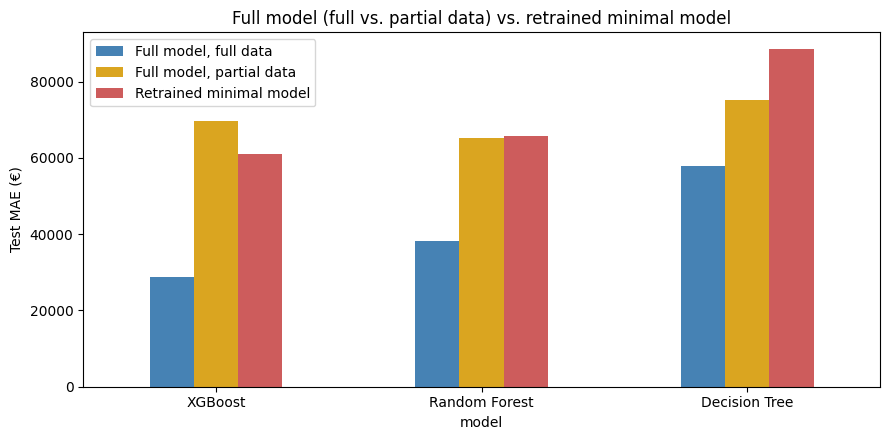

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))

three_way_df[
    ["full_model_full_data_mae_eur", "full_model_partial_data_mae_eur", "retrained_minimal_model_mae_eur"]
].plot(kind="bar", ax=ax, color=["steelblue", "goldenrod", "indianred"])
ax.set_ylabel("Test MAE (€)")
ax.set_title("Full model (full vs. partial data) vs. retrained minimal model")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Full model, full data", "Full model, partial data", "Retrained minimal model"])

plt.tight_layout()
plt.show()

### Summary

| Model | Full model, full data | Full model, partial data (mean-filled) | Retrained minimal model |
|---|---|---|---|
| Decision Tree | €57,964 / 19.40% (R²=0.890) | €75,136 / 24.03% (R²=0.807) | €88,521 / 30.07% (R²=0.747) |
| Random Forest | €38,133 / 12.73% (R²=0.952) | **€65,160 / 20.03%** (R²=0.862) | €65,884 / 22.20% (R²=0.857) |
| XGBoost | **€28,773 / 9.56%** (R²=0.972) | €69,731 / 20.33% (R²=0.843) | **€61,167 / 20.53%** (R²=0.878) |

*(cells show MAE / MAPE)*

**The model ranking flips under partial information — a genuinely useful finding.** XGBoost is clearly the best model when it has all 35 real features (€28,773 / 9.56% MAPE, beating Random Forest by 25%), but when we feed the *same trained model* 32 mean-filled features instead, **Random Forest overtakes it** on both MAE (€65,160 vs. €69,731) and MAPE (20.03% vs. 20.33%) — XGBoost drops to 2nd place. Random Forest is the most robust of the three to this kind of missing-data scenario; it's also the only model where "full model + partial data" (€65,160) and "retrained minimal model" (€65,884) land almost exactly on top of each other.

**Why the flip?** XGBoost's trees are built sequentially, each one correcting the *residual* errors of the previous trees under the assumption that all 35 features carry real, varying information. Freezing 32 of them at a constant "average" value breaks that assumption for every tree in the chain — early splits on now-useless features still fire, and later trees can't fully compensate. Random Forest's trees are independent and bagged: averaging over many trees that each only look at a random feature subset dilutes the damage from the constant-valued features much more gracefully.

**A second pattern, split by model:**
- For **Decision Tree and Random Forest**, keeping the full model and mean-filling unknown features beats retraining a dedicated minimal model on *both* metrics (DT: €75,136/24.03% vs. €88,521/30.07%; RF: €65,160/20.03% vs. €65,884/22.20%) — the full model, even fed mediocre inputs for most features, still has more learned structure to fall back on than a 3-feature model has to work with.
- For **XGBoost**, MAE and MAPE actually disagree: retraining wins clearly on MAE (€61,167 vs. €69,731, -12%), but *loses* slightly on MAPE (20.53% vs. 20.33%). That means the retrained minimal model is more accurate in absolute euros overall, but the mean-filled full model is very slightly more accurate in *relative* terms — plausible if the retrained model's remaining errors skew towards a few large absolute misses on expensive properties (which dominate MAE but barely move MAPE), while the mean-filled model is comparatively worse on expensive properties in euro terms but not by as much percentage-wise. Either way, both approaches land within half a percentage point of each other on MAPE, so this is a genuinely close call for XGBoost — unlike Decision Tree and Random Forest, where mean-filling wins outright on both metrics.

**Practical takeaway:** if you genuinely expect to serve predictions where only `ortsteil`/`area_m2`/`condition` are reliably available, don't just reuse the full XGBoost model with placeholder values for everything else — either retrain a dedicated model on that reduced feature set (best for XGBoost specifically), or use Random Forest, which degrades most gracefully either way.